# EFFIS burnt area — download & basic exploration


## import packages

`geopandas` `rasterio`

In [1]:
# %pip install geopandas matplotlib requests rasterio pyogrio
# # %pip (not !pip) installs into THIS kernel's environment

In [2]:
import requests
import zipfile
import io
import os

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

## Download the burnt area perimeters

This hits the EFFIS WFS endpoint and downloads the burnt-area polygons as a zipped shapefile.


In [3]:
WFS_URL = (
    "https://maps.effis.emergency.copernicus.eu/effis"
    "?service=WFS&request=getfeature&typename=ms:modis.ba.poly"
    "&version=1.1.0&outputformat=SHAPEZIP"
)

DATA_DIR = "effis_data"
os.makedirs(DATA_DIR, exist_ok=True)

# ~320 MB download; skip it if we already have the shapefile
if not any(f.endswith(".shp") for f in os.listdir(DATA_DIR)):
    response = requests.get(WFS_URL, timeout=600)
    response.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall(DATA_DIR)
    print("Downloaded and extracted to:", DATA_DIR)
else:
    print("Shapefile already present, skipping download.")

print("Files:", os.listdir(DATA_DIR))

Shapefile already present, skipping download.
Files: ['modis.ba.poly.shp', 'modis.ba.poly.shx', 'modis.ba.poly.dbf', 'gadm41_PRT_2.json', 'severity_2023.tiff', 'modis.ba.poly.prj']


## Load the shapefile and look at what's inside

In [4]:
# Find the .shp file in the extracted folder
shp_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".shp")]
shp_path = os.path.join(DATA_DIR, shp_files[0])

gdf = gpd.read_file(shp_path)

print("Number of records:", len(gdf))
print("CRS:", gdf.crs)
print("Columns:", list(gdf.columns))
gdf.head()


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyogrio/raw.py:200: RuntimeWarning: effis_data/modis.ba.poly.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Number of records: 105149
CRS: GEOGCS["unknown",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Columns: ['id', 'FIREDATE', 'FINALDATE', 'LASTUPDATE', 'COUNTRY', 'PROVINCE', 'COMMUNE', 'AREA_HA', 'BROADLEA', 'CONIFER', 'MIXED', 'SCLEROPH', 'TRANSIT', 'OTHERNATLC', 'AGRIAREAS', 'ARTIFSURF', 'OTHERLC', 'PERCNA2K', 'CLASS', 'geometry']


,id,FIREDATE,FINALDATE,LASTUPDATE,COUNTRY,PROVINCE,COMMUNE,AREA_HA,BROADLEA,CONIFER,MIXED,SCLEROPH,TRANSIT,OTHERNATLC,AGRIAREAS,ARTIFSURF,OTHERLC,PERCNA2K,CLASS,geometry
0,87,2016-07-27 00:00:00,2016-07-28 00:00:00,2022-01-26 11:57:54.973474,TR,??rnak,N.A.,72,0,0,0,0,70.83333333323495,22.222222222191355,0,6.9444444444348,0,0,FireSeason,"POLYGON ((42.50247 37.53773, 42.5029 37.53451,..."
1,368,2016-08-24 00:00:00,2016-08-25 00:00:00,2022-01-26 11:57:54.973474,IT,Genova,Bogliasco,267,11.654135338341485,5.639097744358783,0.37593984962391885,0,7.894736842102295,74.06015037591202,0.37593984962391885,0,0,5.453094633641743,FireSeason,"POLYGON ((9.06157 44.39255, 9.06266 44.39417, ..."
2,859,2016-09-05 00:00:00,2016-09-06 00:00:00,2022-01-26 11:57:54.973474,PT,Região de Leiria,Caranguejeira,348,78.57142857140612,3.428571428570449,0,0,17.99999999999486,0,0,0,0,0,FireSeason,"POLYGON ((-8.69794 39.76629, -8.69592 39.76992..."
3,424,2016-08-22 00:00:00,2016-08-23 00:00:00,2022-01-26 11:57:54.973474,PT,Beiras e Serra da Estrela,Teixeira,432,0,1.3824884792623542,0,0,10.599078341011383,83.64055299537243,4.377880184330789,0,0,38.26787498738594,FireSeason,"POLYGON ((-7.75329 40.26516, -7.75256 40.26594..."
4,726,2016-08-11 00:00:00,2016-08-12 00:00:00,2022-01-26 11:57:54.973474,MA,Ksar El Keb,N.A.,49,99.9999999998,0,0,0,0,0,0,0,0,0,FireSeason,"POLYGON ((-5.73851 35.13472, -5.73744 35.13311..."


**which column holds the fire date/year, area, and country/commune** — the exact field
names aren't guaranteed in advance, so print `gdf.columns` above and adjust the column names used
below (`YEAR_COL`, `AREA_COL`, etc.) to match what you actually got.


In [ ]:
gdf = gdf.set_crs("EPSG:4326", allow_override=True)

gdf["year"] = pd.to_datetime(gdf["FIREDATE"], format="ISO8601").dt.year
gdf["area_ha"] = pd.to_numeric(gdf["AREA_HA"], errors="coerce")

# Land-cover composition of each burn scar, as % (CLC-derived). TRANSIT = transitional
# woodland-shrub (CLC 324), the successional class abandoned farmland turns into.
LC_COLS = ["BROADLEA", "CONIFER", "MIXED", "SCLEROPH", "TRANSIT",
           "OTHERNATLC", "AGRIAREAS", "ARTIFSURF", "OTHERLC"]
for c in LC_COLS + ["PERCNA2K"]:
    gdf[c] = pd.to_numeric(gdf[c], errors="coerce")

YEAR_COL, AREA_COL = "year", "area_ha"

print("Date range:", gdf.FIREDATE.min(), "->", gdf.FIREDATE.max())
print("AREA_HA values that failed to parse:", int(gdf.area_ha.isna().sum()))
gdf[["year", "area_ha", "COUNTRY", "PROVINCE", "COMMUNE", "TRANSIT", "PERCNA2K"]].head()

Date range:

 2016-02-07 00:00:00 -> 2026-08-25 00:30:00
AREA_HA values that failed to parse: 0


,year,area_ha,COUNTRY,PROVINCE,COMMUNE,TRANSIT,PERCNA2K
0,2016,72,TR,??rnak,N.A.,70.833333,0.000000
1,2016,267,IT,Genova,Bogliasco,7.894737,5.453095
2,2016,348,PT,Região de Leiria,Caranguejeira,18.000000,0.000000
3,2016,432,PT,Beiras e Serra da Estrela,Teixeira,10.599078,38.267875
4,2016,49,MA,Ksar El Keb,N.A.,0.000000,0.000000


## burnt area polygons

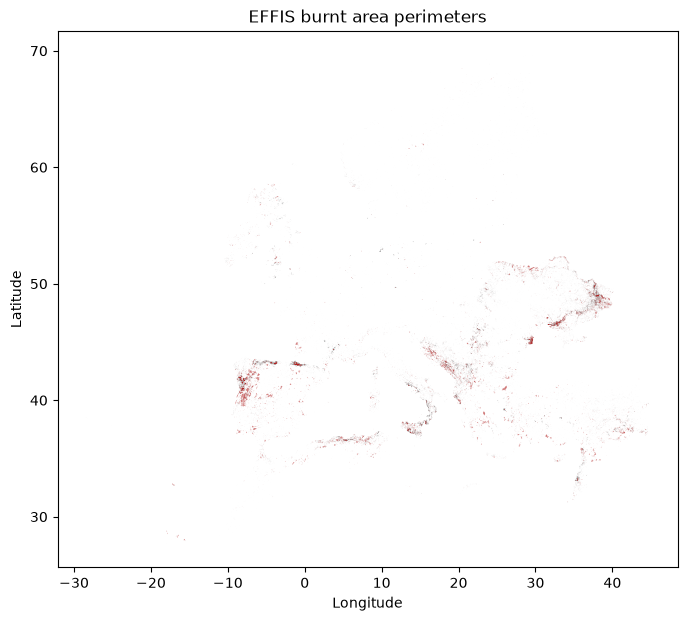

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(ax=ax, color="firebrick", edgecolor="none", alpha=0.6)
ax.set_title("EFFIS burnt area perimeters")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


## Burned area by year 

`YEAR_COL` / `AREA_COL`

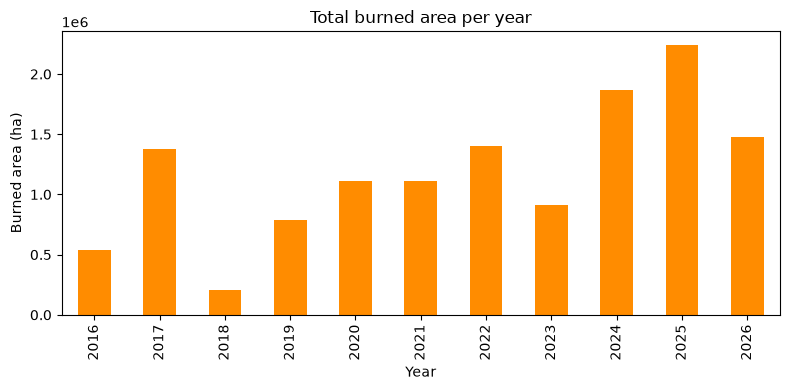

In [7]:
yearly = gdf.groupby(YEAR_COL)[AREA_COL].sum().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
yearly.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Total burned area per year")
ax.set_xlabel("Year")
ax.set_ylabel("Burned area (ha)")
plt.tight_layout()
plt.show()


## Number of fires per year 

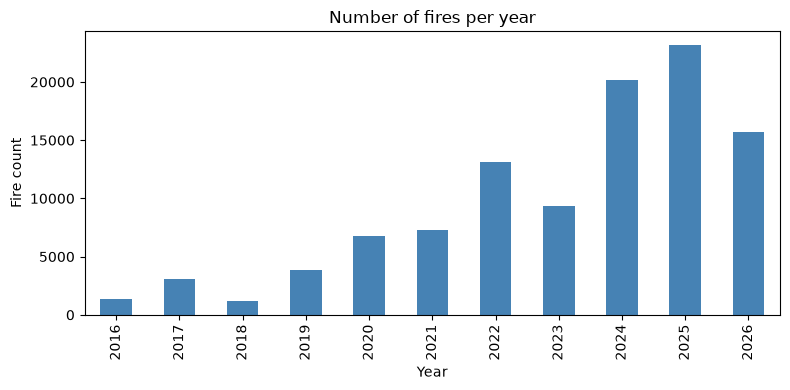

In [8]:
fires_per_year = gdf.groupby(YEAR_COL).size().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
fires_per_year.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Number of fires per year")
ax.set_xlabel("Year")
ax.set_ylabel("Fire count")
plt.tight_layout()
plt.show()


> **It is not a trend off the fire-count chart.** EFFIS lowered its minimum mapped
> fire size over time: the 5th-percentile fire is ~35 ha in 2016-17 but ~1 ha from 2021 on,
> and the median Portuguese fire falls from 131 ha to 5 ha purely from detection changes.
> The post-2021 explosion in fire *counts* is mostly an artefact. Any trend analysis needs a
> constant size floor applied across all years -- that is what `MIN_FIRE_HA` does below.

## plot one fire-severity raster

EFFIS also publishes yearly severity rasters (2018–2025) as plain GeoTIFF downloads.
This is a simple example for one year — change `SEVERITY_YEAR` to try another.


Full raster: 656518 x 359159 px | EPSG:4326 | classes 1-5, nodata 0.0


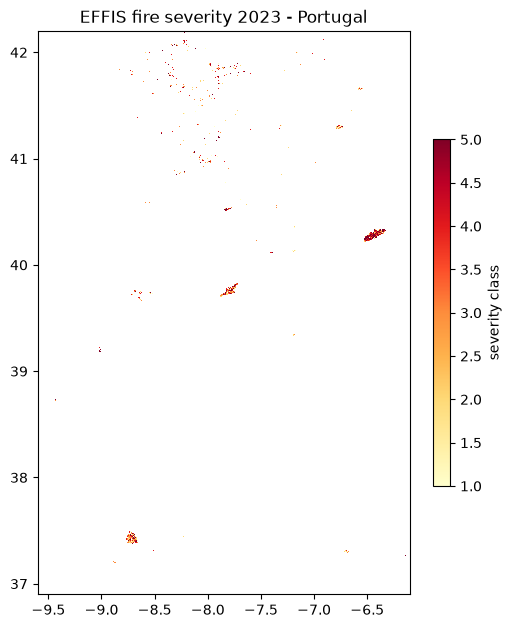

In [9]:
import rasterio
from rasterio.windows import from_bounds

SEVERITY_YEAR = 2023
severity_url = f"https://forest-fire.emergency.copernicus.eu/effis/applications/data-and-services/severity_{SEVERITY_YEAR}.tiff"
severity_path = os.path.join(DATA_DIR, f"severity_{SEVERITY_YEAR}.tiff")

if not os.path.exists(severity_path):
    r = requests.get(severity_url, timeout=600)
    r.raise_for_status()
    with open(severity_path, "wb") as f:
        f.write(r.content)

# This raster is 656,518 x 359,159 px at ~12 m resolution. rasterio.plot.show(src)
# reads the FULL band into memory -- 236 GB -- and will hang or kill the kernel.
# Always read a bounded window, decimated via out_shape.
PT_BOUNDS = (-9.6, 36.9, -6.1, 42.2)  # left, bottom, right, top (mainland Portugal)
L, B, R, T = PT_BOUNDS

with rasterio.open(severity_path) as src:
    print("Full raster:", src.width, "x", src.height, "px |", src.crs, "| classes 1-5, nodata", src.nodata)
    sev = src.read(1, window=from_bounds(L, B, R, T, src.transform),
                   out_shape=(1600, 1100), resampling=rasterio.enums.Resampling.nearest)

fig, ax = plt.subplots(figsize=(6, 9))
im = ax.imshow(np.ma.masked_equal(sev, 0), extent=(L, R, B, T),
               cmap="YlOrRd", vmin=1, vmax=5, interpolation="nearest")
fig.colorbar(im, ax=ax, shrink=0.5, label="severity class")
ax.set_title(f"EFFIS fire severity {SEVERITY_YEAR} - Portugal")
plt.show()

---

# 7. Extracting a multi-country subset

The WFS download is pan-European (and then some -- 50 country codes, reaching into North Africa and
the Middle East). This section cuts it down to whichever countries the project cares about.

**To add or remove a country, edit `COUNTRIES` and re-run the cell.** Nothing else needs to change.

One trap worth knowing about: **EFFIS country codes are not ISO 3166.** Greece is `EL` (not `GR`),
the United Kingdom is `UK` (not `GB`), Kosovo is `KS` (not `XK`). Typing `"GR"` would silently give
you an empty result, so the cell translates the common cases and loudly warns about anything it
cannot find rather than returning nothing.

In [10]:
# =====================================================================
# EDIT THIS BLOCK
# =====================================================================
COUNTRIES = ["PT", "ES", "IT", "FR"]      # add/remove EFFIS country codes here

FIRESEASON_ONLY = True   # drop provisional 1DAY/7DAYS/30DAYS records (see CLASS)
SUBSET_MIN_HA   = None   # e.g. 30 to enforce a constant detection floor; None = keep all
SUBSET_YEARS    = None   # e.g. (2016, 2025) to drop the partial current year; None = keep all
# =====================================================================

# EFFIS uses a few non-ISO codes; translate the usual mistakes rather than returning nothing.
CODE_FIXUPS = {"GR": "EL", "GB": "UK", "XK": "KS"}

available = set(gdf.COUNTRY.dropna().unique())
wanted, notes = [], []
for raw in COUNTRIES:
    c = raw.strip().upper()
    if c not in available and CODE_FIXUPS.get(c) in available:
        notes.append(f"  {c!r} -> {CODE_FIXUPS[c]!r}  (EFFIS uses a non-ISO code)")
        c = CODE_FIXUPS[c]
    if c not in available:
        notes.append(f"  {c!r} NOT FOUND in this download - skipped")
    elif c not in wanted:
        wanted.append(c)

if notes:
    print("Country code notes:")
    print("\n".join(notes), "\n")
if not wanted:
    raise ValueError(f"None of {COUNTRIES} matched. Available codes: {sorted(available)}")

subset = gdf[gdf.COUNTRY.isin(wanted)].copy()
n_raw = len(subset)
if FIRESEASON_ONLY:
    subset = subset[subset.CLASS == "FireSeason"]
if SUBSET_MIN_HA is not None:
    subset = subset[subset.area_ha >= SUBSET_MIN_HA]
if SUBSET_YEARS is not None:
    subset = subset[subset.year.between(*SUBSET_YEARS)]

print(f"{len(gdf):,} records EU-wide"
      f"  ->  {n_raw:,} in {wanted}"
      f"  ->  {len(subset):,} after filters")

105,149 records EU-wide  ->  35,190 in ['PT', 'ES', 'IT', 'FR']  ->  34,383 after filters


## 7.1 What you actually got

`n_nuts3` is the count of distinct `PROVINCE` values, i.e. how many NUTS3 regions the fires touch --
a quick check that the administrative join will have something to bite on. `transit_pct` is the
unweighted mean share of burned area that was transitional woodland-shrub (CLC 324), the
abandonment-fuel proxy.

In [11]:
summary_by_country = (subset.groupby("COUNTRY")
                      .agg(n_fires=("area_ha", "size"),
                           total_ha=("area_ha", "sum"),
                           median_ha=("area_ha", "median"),
                           max_ha=("area_ha", "max"),
                           first_year=("year", "min"),
                           last_year=("year", "max"),
                           transit_pct=("TRANSIT", "mean"),
                           agri_pct=("AGRIAREAS", "mean"),
                           n_nuts3=("PROVINCE", "nunique"))
                      .round(1))
print(summary_by_country.to_string(), "\n")

print("Fires per year by country:")
print(pd.crosstab(subset.year, subset.COUNTRY, margins=True).to_string())

         n_fires  total_ha  median_ha  max_ha  first_year  last_year  transit_pct  agri_pct  n_nuts3
COUNTRY                                                                                             
ES          9117   1500311       15.0   42458        2016       2026          4.7       6.8       57
FR          6606    395398       14.0   37191        2016       2026          4.3       5.7       74
IT         11370    850163       22.0   13278        2016       2026          9.3      24.6      188
PT          7290   1522556       11.0   67521        2016       2026         26.3       6.7       25 

Fires per year by country:
COUNTRY    ES    FR     IT    PT    All
year                                   
2016      128    28    145   322    623
2017      322    92    788   414   1616
2018      104    23    147    86    360
2019      424   370    448   222   1464
2020      472   260   1127   465   2324
2021      900   588   1422   749   3659
2022     1490  1088   1426  1236   5240
2023 

## 7.2 Comparable burned-area series

Plotted with a 30 ha floor and the partial current year dropped, because the raw series is not
comparable across years (EFFIS lowered its minimum mapped fire size around 2020 -- see the note in
section 5). This floor is applied *for the plot only*; it does not touch `subset`.

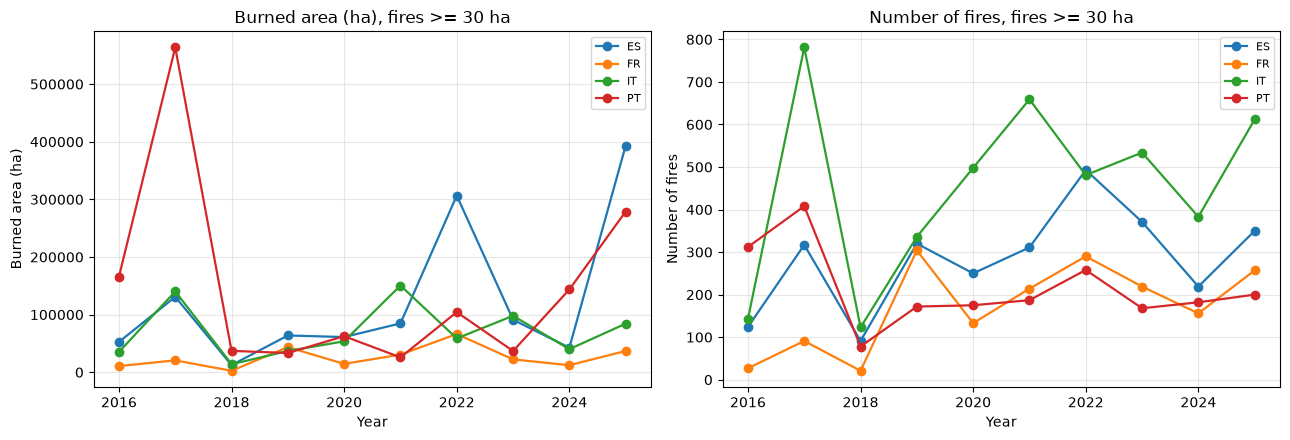

In [12]:
LAST_FULL_YEAR = int(gdf.year.max()) - 1
plotdf = subset[(subset.area_ha >= 30) & (subset.year <= LAST_FULL_YEAR)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (col, label) in zip(axes, [("sum", "Burned area (ha)"), ("size", "Number of fires")]):
    series = plotdf.groupby(["year", "COUNTRY"]).area_ha.agg(col).unstack()
    series.plot(ax=ax, marker="o", linewidth=1.6)
    ax.set_ylabel(label)
    ax.set_xlabel("Year")
    ax.set_title(f"{label}, fires >= 30 ha")
    ax.grid(alpha=0.3)
    ax.legend(title=None, fontsize=8)
plt.tight_layout()
plt.show()

## 7.3 Export

Written as GeoPackage (keeps geometry, CRS and numeric dtypes in one file) plus a plain CSV of the
attributes for anyone who does not need the polygons. Filenames carry the country codes, so
different subsets do not overwrite each other.

The derived columns are renamed on the way out (`year` -> `fire_year`, `area_ha` -> `burn_ha`)
because GeoPackage column names are **case-insensitive**: `area_ha` collides with the original
`AREA_HA` and GDAL refuses to create the layer.

In [13]:
tag = "-".join(sorted(wanted))
export = subset.rename(columns={"year": "fire_year", "area_ha": "burn_ha"})
export["burn_ha"] = export.burn_ha.astype("float64")

gpkg_path = f"effis_subset_{tag}.gpkg"
csv_path = f"effis_subset_{tag}.csv"
export.to_file(gpkg_path, driver="GPKG", layer="burnt_area")
export.drop(columns="geometry").to_csv(csv_path, index=False)

print(f"wrote {gpkg_path}  ({len(export):,} polygons)")
print(f"wrote {csv_path}   ({export.shape[1] - 1} columns)")
print("\nreload with:  subset = gpd.read_file(f'effis_subset_{tag}.gpkg')")

wrote effis_subset_ES-FR-IT-PT.gpkg  (34,383 polygons)
wrote effis_subset_ES-FR-IT-PT.csv   (21 columns)

reload with:  subset = gpd.read_file(f'effis_subset_{tag}.gpkg')


> Section 8 below stays Portugal-only: it downloads Portuguese municipal boundaries and produces
> the PT deliverable. To run that municipal pipeline for Spain, Italy or France, swap the GADM URL
> for that country's level-2 file (`gadm41_ESP_2`, `gadm41_ITA_2`, `gadm41_FRA_2`) and check what
> `CC_2` holds there -- the code column is country-specific and is *not* an INE DICO outside
> Portugal.

---

# 8. Building the municipality x year fire panel

This is the deliverable the rest of the group needs: one row per (municipality, year), keyed on a
code that also joins to Corine Land Cover, Eurostat and ICNF.

Two problems have to be solved before aggregating:

1. **`COMMUNE` is the *freguesia*, not the *concelho*.** 1,374 distinct values appear in the
   Portuguese subset, with names like `Trancoso (São Pedro e Santa Maria) e Souto Maior` -- those
   are post-2013 merged civil parishes. Portugal has 3,092 freguesias but only 308 municipalities.
   It is also a free-text name with no code attached.
2. **`AREA_HA` is the whole polygon's area, tagged to a single parish.** It matches the polygon's
   own geometry to within 1%, so a 67,521 ha fire gets charged entirely to one parish label.
   Grouping by `COMMUNE` therefore misattributes exactly the large cross-boundary fires that matter
   most here.

The fix for both is the same: ignore `COMMUNE`, intersect the fire polygons with official municipal
boundaries, and recompute area per resulting piece in an equal-area CRS.

`PROVINCE` is clean, by contrast -- 25 values, exactly Portugal's NUTS3 regions -- so it joins
straight to Eurostat's NUTS3 demography without any of this work.

## 8.1 Municipal boundaries

GADM level 2 for Portugal is 308 polygons -- exactly the 308 concelhos -- and carries `CC_2`, the
INE **DICO** code (district + municipality, e.g. `0612` = Pampilhosa da Serra). That code is the
join key to CLC-derived statistics, Eurostat and ICNF.

Caveat: the 23 island municipalities (Azores, Madeira) have `CC_2 = "NA"`, so `GID_2` is used as the
guaranteed-unique key and DICO is carried alongside. GADM's `NAME_2` also strips spaces
(`CastelodePaiva`) -- fine as a label, never join on it.

For a client deliverable to ICNF, swap this for the official **CAOP** boundaries from DGT; the rest
of the code is unchanged as long as you keep a unique key column and a DICO column.

In [14]:
MUNI_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_PRT_2.json.zip"
muni_path = os.path.join(DATA_DIR, "gadm41_PRT_2.json")

if not os.path.exists(muni_path):
    r = requests.get(MUNI_URL, timeout=180)
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall(DATA_DIR)

muni = gpd.read_file(muni_path)[["GID_2", "CC_2", "NAME_1", "NAME_2", "geometry"]]
muni = muni.rename(columns={"CC_2": "dico", "NAME_1": "district", "NAME_2": "municipality"})
muni["geometry"] = muni.geometry.make_valid()
muni["muni_ha"] = muni.to_crs(3035).area / 1e4   # EPSG:3035 = LAEA Europe, equal-area

print("municipalities:", len(muni), "| unique DICO codes:", muni.dico.nunique(),
      "| islands without a code:", int((muni.dico == "NA").sum()))
muni.head(3)

municipalities: 308 | unique DICO codes: 286 | islands without a code: 23


,GID_2,dico,district,municipality,geometry,muni_ha
0,PRT.1.1_1,0101,Aveiro,Águeda,"MULTIPOLYGON (((-8.4357 40.5076, -8.4408 40.50...",33548.482195
1,PRT.1.2_1,0102,Aveiro,Albergaria-a-Velha,"MULTIPOLYGON (((-8.5283 40.6095, -8.5343 40.61...",15766.618661
2,PRT.1.3_1,0103,Aveiro,Anadia,"MULTIPOLYGON (((-8.3448 40.423, -8.3404 40.421...",21687.287288


## 8.2 Filter the fires

`MIN_FIRE_HA = 30` keeps the series comparable across years (see the detection-threshold note
above). 2026 is dropped because it is a partial year -- the WFS layer updates daily.

In [15]:
MIN_FIRE_HA = 30
YEARS = (2016, 2025)

fires = gdf[gdf.COUNTRY == "PT"].copy()
fires["geometry"] = fires.geometry.make_valid()
fires = fires[(fires.area_ha >= MIN_FIRE_HA) & (fires.year.between(*YEARS))]

print(f"Portuguese fires >= {MIN_FIRE_HA} ha, {YEARS[0]}-{YEARS[1]}: {len(fires)}")
print(f"Total burned area: {fires.area_ha.sum():,.0f} ha")

Portuguese fires >= 30 ha, 2016-2025: 2140
Total burned area: 1,452,225 ha


## 8.3 Split fires at municipal borders

`gpd.overlay(..., how="intersection")` cuts every fire polygon at the municipal boundaries, so a
fire spanning three municipalities becomes three rows, each with its own recomputed area. Area is
conserved to ~0.01% (the small loss is geometry-validity cleanup).

In [16]:
KEEP = ["year", "area_ha"] + LC_COLS + ["PERCNA2K", "geometry"]

pieces = gpd.overlay(fires[KEEP], muni, how="intersection", keep_geom_type=True)
pieces["burn_ha"] = pieces.to_crs(3035).area / 1e4

print(f"{len(fires)} fires -> {len(pieces)} municipality-level pieces "
      f"({len(pieces) - len(fires)} cross-boundary splits)")
print(f"Area check: {pieces.burn_ha.sum():,.0f} ha after split vs "
      f"{fires.area_ha.sum():,.0f} ha before "
      f"({100 * (1 - pieces.burn_ha.sum() / fires.area_ha.sum()):+.3f}% difference)")

2140 fires -> 2966 municipality-level pieces (826 cross-boundary splits)
Area check: 1,452,033 ha after split vs 1,452,225 ha before (+0.013% difference)


## 8.4 Aggregate to the panel

Land-cover shares are averaged **weighted by burned area**, so a 20,000 ha fire counts for more than
a 30 ha one when describing what a municipality's fires burn through.

In [17]:
def _agg(d):
    w = d.burn_ha
    return pd.Series({
        "burn_ha": w.sum(),
        "n_fires": len(d),
        "max_fire_ha": w.max(),
        "transit_pct": np.average(d.TRANSIT.fillna(0), weights=w),      # abandonment-fuel proxy
        "scleroph_pct": np.average(d.SCLEROPH.fillna(0), weights=w),
        "agri_pct": np.average(d.AGRIAREAS.fillna(0), weights=w),
        "forest_pct": np.average((d.BROADLEA.fillna(0) + d.CONIFER.fillna(0)
                                  + d.MIXED.fillna(0)), weights=w),
        "n2k_pct": np.average(d.PERCNA2K.fillna(0), weights=w),         # % inside Natura 2000
    })


GROUP = ["GID_2", "dico", "district", "municipality", "year"]
panel = pieces.groupby(GROUP).apply(_agg, include_groups=False).reset_index()
panel = panel.merge(muni[["GID_2", "muni_ha"]], on="GID_2")
panel["burn_pct_of_muni"] = 100 * panel.burn_ha / panel.muni_ha

print(f"panel: {len(panel)} rows, {panel.GID_2.nunique()} municipalities with >= 1 qualifying fire")
panel.sort_values("burn_ha", ascending=False).head(10).round(1)

panel: 1013 rows, 238 municipalities with >= 1 qualifying fire


,GID_2,dico,district,municipality,year,burn_ha,n_fires,max_fire_ha,transit_pct,scleroph_pct,agri_pct,forest_pct,n2k_pct,muni_ha,burn_pct_of_muni
344,PRT.16.13_1,1413,Santarém,Mação,2017,28610.6,4.0,18267.6,53.5,1.5,18.7,22.9,4.3,39997.6,71.5
936,PRT.7.12_1,0612,Coimbra,PampilhosadaSerra,2017,25528.0,4.0,13783.4,40.0,0.0,3.4,19.8,1.1,39689.3,64.3
951,PRT.7.1_1,0601,Coimbra,Arganil,2017,23142.0,6.0,11453.9,33.3,0.0,21.2,34.1,8.6,33280.2,69.5
930,PRT.7.11_1,0611,Coimbra,OliveiradoHospital,2017,23112.6,3.0,22993.2,32.4,0.0,29.2,30.6,15.0,23404.3,98.8
902,PRT.6.3_1,0503,CasteloBranco,Covilhã,2025,21685.9,2.0,16281.4,48.8,0.0,6.7,17.9,13.4,55535.5,39.0
75,PRT.10.11_1,0911,Guarda,Sabugal,2025,20939.2,1.0,20939.2,35.1,0.0,21.6,2.2,12.8,82205.1,25.5
77,PRT.10.12_1,0912,Guarda,Seia,2017,19869.2,3.0,15277.0,28.1,0.0,27.1,27.3,27.6,43634.9,45.5
90,PRT.10.13_1,0913,Guarda,Trancoso,2025,18343.9,2.0,17473.1,29.6,0.3,32.9,6.6,0.0,36167.6,50.7
605,PRT.20.18_1,1818,Viseu,Sernancelhe,2025,17703.9,3.0,11341.6,33.3,0.2,27.1,11.1,1.0,22893.6,77.3
925,PRT.6.9_1,0509,CasteloBranco,Sertã,2017,17648.5,7.0,7889.2,41.6,0.1,7.7,23.9,1.7,44667.5,39.5


## 8.5 Collapse to one row per municipality

Two different exposure measures, and they answer different questions:

- **`burn_ratio_pct`** -- cumulative burned area / municipal area. Counts reburns repeatedly, so it
  can exceed 100%. This is *fire pressure*, and it is the one that speaks to recurring management cost.
- **`ever_burnt_pct`** -- the dissolved union of all burn scars / municipal area. Caps at 100%.
  This is *spatial extent*: how much of the municipality has seen fire at all.

`years_burnt` (how many distinct years had a qualifying fire) is the recurrence measure to pair with
the abandonment trend -- a municipality that burns in 9 of 10 years is a different management problem
from one that burned catastrophically once.

In [18]:
# unique burnt footprint: dissolve all fire polygons, then clip to each municipality
footprint = gpd.GeoDataFrame(geometry=[fires.union_all()], crs=fires.crs)
ever = gpd.overlay(muni, footprint, how="intersection", keep_geom_type=True)
ever["ever_burnt_ha"] = ever.to_crs(3035).area / 1e4
ever = ever.groupby("GID_2")["ever_burnt_ha"].sum().reset_index()

summary = (panel.groupby(["GID_2", "dico", "district", "municipality", "muni_ha"])
           .agg(burn_ha=("burn_ha", "sum"),
                n_fires=("n_fires", "sum"),
                years_burnt=("year", "nunique"),
                max_fire_ha=("max_fire_ha", "max"),
                transit_pct=("transit_pct", "mean"),
                agri_pct=("agri_pct", "mean"),
                n2k_pct=("n2k_pct", "mean"))
           .reset_index())

# every municipality gets a row, including the ones that never burned
summary = (muni[["GID_2", "dico", "district", "municipality", "muni_ha"]]
           .merge(summary.drop(columns=["dico", "district", "municipality", "muni_ha"]),
                  on="GID_2", how="left")
           .merge(ever, on="GID_2", how="left"))
summary[["burn_ha", "n_fires", "years_burnt", "ever_burnt_ha"]] = \
    summary[["burn_ha", "n_fires", "years_burnt", "ever_burnt_ha"]].fillna(0)

summary["burn_ratio_pct"] = 100 * summary.burn_ha / summary.muni_ha
summary["ever_burnt_pct"] = 100 * summary.ever_burnt_ha / summary.muni_ha

print(f"{len(summary)} municipalities | "
      f"{int((summary.burn_ha == 0).sum())} with no qualifying fire {YEARS[0]}-{YEARS[1]}")
summary.sort_values("ever_burnt_pct", ascending=False).head(15).round(1)

308 municipalities | 70 with no qualifying fire 2016-2025


,GID_2,dico,district,municipality,muni_ha,burn_ha,n_fires,years_burnt,max_fire_ha,transit_pct,agri_pct,n2k_pct,ever_burnt_ha,burn_ratio_pct,ever_burnt_pct
99,PRT.7.11_1,0611,Coimbra,OliveiradoHospital,23404.3,29273.1,10.0,5.0,22993.2,47.6,17.8,38.8,23131.6,125.1,98.8
297,PRT.20.14_1,1814,Viseu,SantaCombaDão,11187.7,10337.6,1.0,1.0,10337.6,20.4,22.5,1.0,10337.6,92.4,92.4
238,PRT.16.13_1,1413,Santarém,Mação,39997.6,34303.7,5.0,2.0,18267.6,58.5,13.5,2.2,34065.6,85.8,85.2
295,PRT.20.12_1,1812,Viseu,Penedono,13324.0,12117.2,3.0,3.0,10629.0,39.8,27.6,0.0,10631.0,90.9,79.8
100,PRT.7.12_1,0612,Coimbra,PampilhosadaSerra,39689.3,32023.3,12.0,5.0,13783.4,62.7,2.9,2.3,31483.5,80.7,79.3
162,PRT.11.13_1,1013,Leiria,PedrógãoGrande,12874.8,10399.8,4.0,2.0,8789.7,21.2,6.0,2.1,10069.8,80.8,78.2
301,PRT.20.18_1,1818,Viseu,Sernancelhe,22893.6,21588.3,13.0,5.0,11341.6,25.5,15.3,0.2,17896.1,94.3,78.2
89,PRT.7.1_1,0601,Coimbra,Arganil,33280.2,35184.7,11.0,5.0,11453.9,31.1,6.5,23.0,25955.7,105.7,78.0
307,PRT.20.24_1,1824,Viseu,Vouzela,19365.1,13655.2,6.0,3.0,7625.2,56.2,22.3,0.0,13643.0,70.5,70.5
141,PRT.10.6_1,0906,Guarda,Gouveia,30031.1,24535.0,26.0,9.0,7180.6,19.1,6.4,80.7,20979.1,81.7,69.9


## 8.6 Export for the group

`dico` is the join key. Hand these two files to whoever owns the CLC and Eurostat sources.

**Read the caveats into the handoff, not just the CSV:** the size floor, the fact that EFFIS is
MODIS-based (250 m) and so misses small fires that ICNF's ground statistics capture, and that the
fire record starts in 2016 while the CLC change layers end in 2018.

In [19]:
panel.round(3).to_csv("effis_pt_municipality_year_panel.csv", index=False)
summary.round(3).to_csv("effis_pt_municipality_summary.csv", index=False)
summary_gdf = muni[["GID_2", "geometry"]].merge(summary, on="GID_2")
summary_gdf.to_file("effis_pt_municipality_summary.gpkg", driver="GPKG")

print("wrote:")
print("  effis_pt_municipality_year_panel.csv ", panel.shape)
print("  effis_pt_municipality_summary.csv    ", summary.shape)
print("  effis_pt_municipality_summary.gpkg   (same, with geometry)")

wrote:
  effis_pt_municipality_year_panel.csv  (1013, 15)
  effis_pt_municipality_summary.csv     (308, 15)
  effis_pt_municipality_summary.gpkg   (same, with geometry)


## 8.7 Where the fire side of the story already points

Two maps: cumulative exposure, and the transitional-woodland-shrub share of what burned. The second
is EFFIS's own abandonment-fuel signal, and it is the cheap validation target for the CLC work --
if the group's CLC-derived abandonment index is measuring the right thing, it should line up with
where fires are burning through CLC 324.

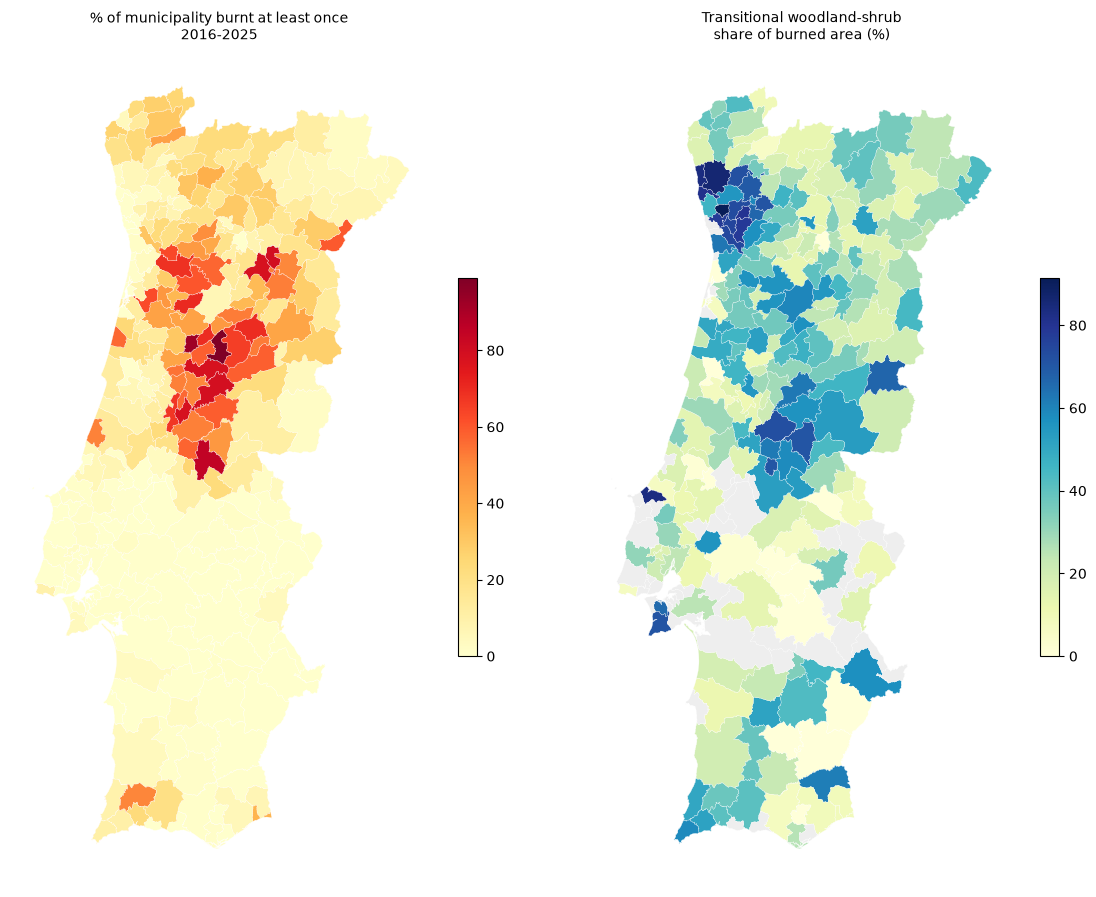

In [20]:
mainland = summary_gdf.cx[-10:-6, 36.5:42.5]

fig, axes = plt.subplots(1, 2, figsize=(12, 9))
for ax, col, cmap, title in [
    (axes[0], "ever_burnt_pct", "YlOrRd", f"% of municipality burnt at least once\n{YEARS[0]}-{YEARS[1]}"),
    (axes[1], "transit_pct", "YlGnBu", "Transitional woodland-shrub\nshare of burned area (%)"),
]:
    mainland.plot(column=col, ax=ax, cmap=cmap, legend=True, edgecolor="white", linewidth=0.2,
                  missing_kwds={"color": "#eeeeee"}, legend_kwds={"shrink": 0.45})
    ax.set_axis_off()
    ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.show()

In [21]:
# Candidate priority municipalities: burnt a lot, burnt repeatedly, and burning through scrub.
# This is the fire half of the targeting question -- the abandonment TREND still has to come from
# CLC/Eurostat before any of this can be called a funding recommendation.
cand = summary[(summary.years_burnt >= 4) & (summary.ever_burnt_pct >= 20)].copy()
cand["rank_score"] = (cand.ever_burnt_pct.rank(pct=True)
                      + cand.years_burnt.rank(pct=True)
                      + cand.transit_pct.rank(pct=True))

cols = ["dico", "municipality", "district", "ever_burnt_pct", "burn_ratio_pct",
        "years_burnt", "n_fires", "transit_pct", "n2k_pct"]
print(f"{len(cand)} municipalities meet both thresholds. Top 20 by combined rank:\n")
print(cand.sort_values("rank_score", ascending=False)[cols].head(20).round(1).to_string(index=False))

65 municipalities meet both thresholds. Top 20 by combined rank:

dico         municipality       district  ever_burnt_pct  burn_ratio_pct  years_burnt  n_fires  transit_pct  n2k_pct
0912                 Seia         Guarda            65.4            78.2          9.0     26.0         40.0     35.2
0612    PampilhosadaSerra        Coimbra            79.3            80.7          5.0     12.0         62.7      2.3
0104               Arouca         Aveiro            68.4            89.9          8.0     29.0         35.8     52.0
0611   OliveiradoHospital        Coimbra            98.8           125.1          5.0     10.0         47.6     38.8
1302                Baião          Porto            49.4            69.0         10.0     50.0         29.8     20.5
0503              Covilhã  CasteloBranco            58.4            65.1          8.0     22.0         35.4     38.4
1604               Monção VianadoCastelo            27.6            30.4         10.0     23.0         43.1      0.